In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import networkx as nx
from loguru import logger

In [2]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# 0. Load dataset

In [3]:
path = "pvldb.xlsx"

df = pd.read_excel(path)

In [4]:
df.head()

,COAUTHOR,REVIEWER,REVIEWER DBLP,CO-AUTHORSHIP 3 YEARS
0,fabio azzalini,letizia tanca,https://dblp.org/pers/t/Tanca:Letizia.html,"[(2022, 3), (2021, 4), (2020, 1)]"
1,chiara criscuolo,letizia tanca,https://dblp.org/pers/t/Tanca:Letizia.html,"[(2022, 3), (2021, 2)]"
2,davide azzalini,letizia tanca,https://dblp.org/pers/t/Tanca:Letizia.html,"[(2022, 3)]"
3,fabio alberto schreiber,letizia tanca,https://dblp.org/pers/t/Tanca:Letizia.html,"[(2022, 2), (2021, 1), (2020, 2)]"
4,emanuele rabosio,letizia tanca,https://dblp.org/pers/t/Tanca:Letizia.html,"[(2022, 2), (2021, 1)]"


# 1. Build graph

In [5]:
G = nx.Graph()

In [6]:
edges = dict()

for r in df.itertuples():
    pair = f"{r.COAUTHOR}-{r.REVIEWER}"

    if not isinstance(r._4, float):
        co_auth = eval(r._4)
        total = sum(x[1] for x in co_auth)

        G.add_edge(r.COAUTHOR, r.REVIEWER, co_auth=total)
        

In [7]:
weights = np.array(list(nx.get_edge_attributes(G, 'co_auth').values()), dtype=np.float32)

In [8]:
num_nodes = nx.number_of_nodes(G)
num_edges = nx.number_of_edges(G)
num_conc_comp = len(list(nx.connected_components(G)))
q75 = np.quantile(weights, 0.75)
q90 = np.quantile(weights, 0.9)

print(f"Number of nodes                       : {num_nodes}")
print(f"Number of edges                       : {num_edges}")
print(f"Number of connected components        : {num_conc_comp}")
print(f"Edge weight distribution's 75 quantile: {q75}")
print(f"Edge weight distribution's 90 quantile: {q90}")

Number of nodes                       : 9917
Number of edges                       : 14131
Number of connected components        : 6
Edge weight distribution's 75 quantile: 2.0
Edge weight distribution's 90 quantile: 4.0


<Axes: ylabel='Count'>

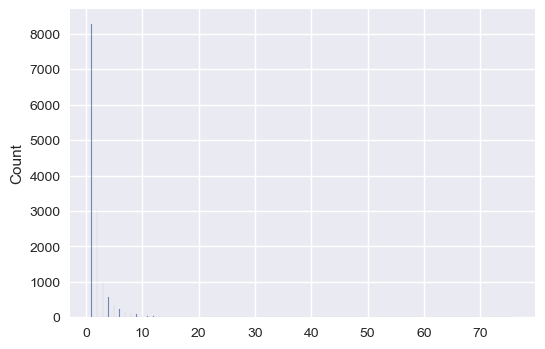

In [9]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
sns.histplot(weights, ax=ax)

# 2. Build subgraphs

## 2.1. Build subgraphs

In [10]:
G_75, G_90 = nx.Graph(), nx.Graph()

In [11]:
for (u, v), w in nx.get_edge_attributes(G, 'co_auth').items():
    if w >= q75:
        G_75.add_edge(u, v, co_auth=w)
    if w >= q90:
        G_90.add_edge(u, v, co_auth=w)

## 2.2. Calculate statistics

In [12]:
G_75_num_conn_com, G_90_num_conn_com = 0, 0

for c in nx.connected_components(G_75):
    if len(c) >= 2:
        G_75_num_conn_com += 1

for c in nx.connected_components(G_90):
    if len(c) >= 2:
        G_90_num_conn_com += 1

In [13]:
G_75_num_edges, G_90_num_edges = nx.number_of_edges(G_75), nx.number_of_edges(G_90)

In [14]:
print(f"Num. edges of G_75                                      : {G_75_num_edges}")
print(f"Num. edges of G_90                                      : {G_90_num_edges}")
print(f"Num. connected components having at least 1 edge in G_75: {G_75_num_conn_com}")
print(f"Num. connected components having at least 1 edge in G_90: {G_90_num_conn_com}")

Num. edges of G_75                                      : 5855
Num. edges of G_90                                      : 1806
Num. connected components having at least 1 edge in G_75: 23
Num. connected components having at least 1 edge in G_90: 83


## 2.3. Node centrality

In [15]:
def get_topn(r: dict, topn: int = 5):
    return sorted([(node, v) for node, v in r.items()], key=lambda x: x[1], reverse=True)[:topn]

In [16]:
graphs = [('G_75', G_75), ('G_90', G_90)]

= Graph: G_75: nth_component = 0
= Graph: G_75: nth_component = 1
= Graph: G_75: nth_component = 2
= Graph: G_75: nth_component = 3
= Graph: G_75: nth_component = 4
= Graph: G_90: nth_component = 0
= Graph: G_90: nth_component = 1
= Graph: G_90: nth_component = 2
= Graph: G_90: nth_component = 3
= Graph: G_90: nth_component = 4


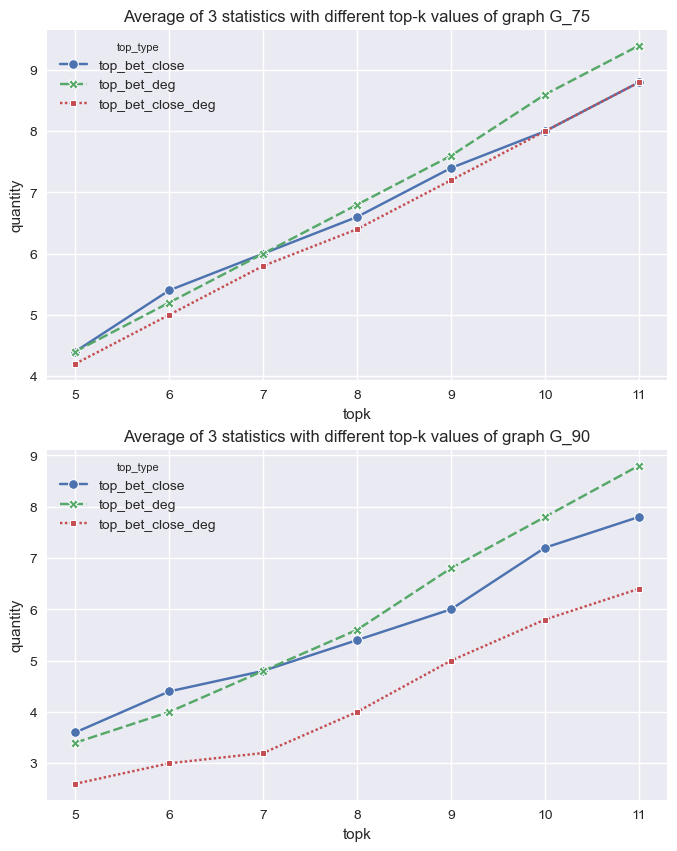

In [31]:

fig = plt.figure(figsize=(8, 10))

for idx_graph, (Gname, Gsub) in enumerate(graphs):
    components = list(nx.connected_components(Gsub))
    components.sort(key=lambda x: len(x), reverse=True)
    components = components[:5]

    results = []
    for nth_comp, c in enumerate(components):
        print(f"= Graph: {Gname}: nth_component = {nth_comp}")

        g = Gsub.subgraph(c)

        degree = nx.degree(g)
        closeness = nx.closeness_centrality(g)
        betweenness = nx.betweenness_centrality(g)

        for i in range(5, 12):
            top_betweenness = get_topn(betweenness, i)
            top_closeness = get_topn(closeness, i)
            top_degree = get_topn(dict(degree), i)

            top_betweenness = set([x[0] for x in top_betweenness])
            top_closeness = set([x[0] for x in top_closeness])
            top_degree = set([x[0] for x in top_degree])

            top_bet_close = len(top_betweenness.intersection(top_closeness))
            top_bet_deg = len(top_betweenness.intersection(top_degree))
            top_bet_close_deg = len(top_betweenness.intersection(top_closeness).intersection(top_degree))

            results.append({
                'nth_component': nth_comp,
                'topk': i,
                'top_bet_close': top_bet_close,
                'top_bet_deg': top_bet_deg,
                'top_bet_close_deg': top_bet_close_deg,
            })

    # Build dataframe
    df_results = pd.DataFrame.from_records(results)
    df_tmp = df_results.groupby(by='topk')\
        .mean()\
        .reset_index()\
        .drop(columns=['nth_component'])\
        .melt(id_vars='topk', value_vars=['top_bet_close', 'top_bet_deg', 'top_bet_close_deg'],
            value_name='quantity', var_name='top_type')
    
    # Visualize data
    ax = fig.add_subplot(2, 1, idx_graph + 1)

    sns.lineplot(df_tmp, x='topk', y='quantity', hue='top_type', 
                ax=ax, style="top_type", markers=True)
    ax.set_title(f"Average of 3 statistics with different top-k values of graph {Gname}")


### 2.3.1. DBLP investigation

In [38]:
df1 = df.copy()

In [41]:
def extract_total(v):
    out = None
    if not isinstance(v, float):
        co_auth = eval(v)
        out = sum(x[1] for x in co_auth)
    else:
        out = v

    return out

df1.loc[:, 'TOTAL'] = df1['CO-AUTHORSHIP 3 YEARS'].apply(extract_total)

df1.head()

,COAUTHOR,REVIEWER,REVIEWER DBLP,CO-AUTHORSHIP 3 YEARS,TOTAL
0,fabio azzalini,letizia tanca,https://dblp.org/pers/t/Tanca:Letizia.html,"[(2022, 3), (2021, 4), (2020, 1)]",8.0
1,chiara criscuolo,letizia tanca,https://dblp.org/pers/t/Tanca:Letizia.html,"[(2022, 3), (2021, 2)]",5.0
2,davide azzalini,letizia tanca,https://dblp.org/pers/t/Tanca:Letizia.html,"[(2022, 3)]",3.0
3,fabio alberto schreiber,letizia tanca,https://dblp.org/pers/t/Tanca:Letizia.html,"[(2022, 2), (2021, 1), (2020, 2)]",5.0
4,emanuele rabosio,letizia tanca,https://dblp.org/pers/t/Tanca:Letizia.html,"[(2022, 2), (2021, 1)]",3.0


In [64]:
components = list(nx.connected_components(G_90))
components.sort(key=lambda x: len(x), reverse=True)
components = components[:5]

In [84]:
c = components[0]
df_c = df1[(df1['REVIEWER'].isin(c)) & (df1['COAUTHOR'].isin(c))]

df_c.head()

,COAUTHOR,REVIEWER,REVIEWER DBLP,CO-AUTHORSHIP 3 YEARS,TOTAL
38,xuemin lin 0001,wenjie zhang,https://dblp.org/pers/hd/z/Zhang_0001:Wenjie,"[(2022, 28), (2021, 25), (2020, 23)]",76.0
39,ying zhang 0001,wenjie zhang,https://dblp.org/pers/hd/z/Zhang_0001:Wenjie,"[(2022, 16), (2021, 16), (2020, 20)]",52.0
40,lu qin 0001,wenjie zhang,https://dblp.org/pers/hd/z/Zhang_0001:Wenjie,"[(2022, 12), (2021, 8), (2020, 14)]",34.0
41,you peng,wenjie zhang,https://dblp.org/pers/hd/z/Zhang_0001:Wenjie,"[(2022, 7), (2021, 3), (2020, 2)]",12.0
42,kai wang 0037,wenjie zhang,https://dblp.org/pers/hd/z/Zhang_0001:Wenjie,"[(2022, 6), (2021, 6), (2020, 4)]",16.0


In [86]:
df_c.groupby(by=['REVIEWER'])['TOTAL'].max().sort_values(ascending=False).head(20)

REVIEWER
wenjie zhang       76.0
guoren wang        64.0
ye yuan            64.0
bin cui            54.0
lu qin             52.0
bolin ding         49.0
zi huang           41.0
yan zhao           37.0
ronghua li         32.0
jianliang xu       30.0
yingxia shao       29.0
guoliang li        28.0
chengliang chai    28.0
jiawei jiang       26.0
meihui zhang       25.0
yanyan shen        24.0
xiaoyang wang      24.0
ce zhang           23.0
lei chen           22.0
xin huang          21.0
Name: TOTAL, dtype: float64

In [83]:
reviewer = 'chengfei liu'

df_c[df_c['REVIEWER'] == reviewer].head()

,COAUTHOR,REVIEWER,REVIEWER DBLP,CO-AUTHORSHIP 3 YEARS,TOTAL
11639,rui zhou 0001,chengfei liu,https://dblp.org/pers/l/Liu:Chengfei.html,"[(2022, 8), (2021, 13), (2020, 13)]",34.0
11640,jiajie xu 0001,chengfei liu,https://dblp.org/pers/l/Liu:Chengfei.html,"[(2022, 6), (2021, 10), (2020, 8)]",24.0
11641,jianxin li 0001,chengfei liu,https://dblp.org/pers/l/Liu:Chengfei.html,"[(2022, 6), (2021, 3), (2020, 2)]",11.0
11642,lu chen 0008,chengfei liu,https://dblp.org/pers/l/Liu:Chengfei.html,"[(2022, 5), (2021, 5), (2020, 7)]",17.0
11643,yun yang 0001,chengfei liu,https://dblp.org/pers/l/Liu:Chengfei.html,"[(2022, 2), (2021, 1), (2020, 2)]",5.0


## 2.4. Graph visualization

### 2.4.1. Filter

In [21]:
e75, e90 = [], []

for e, w in nx.get_edge_attributes(G_75, 'co_auth').items():
    if w >= q90:
        e90.append(e)
    else:
        e75.append(e)

In [22]:
reviewers_all = set(df['REVIEWER'].unique())
coauthors_all = set(df['COAUTHOR'].unique())

reviewers, coauthors = [], []

for node in G_75.nodes:
    if node in reviewers_all:
        reviewers.append(node)
    else:
        coauthors.append(node)

### 2.4.2. Visualize

In [24]:
def draw(layout, layout_name):

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)

    # Draw nodes
    nx.draw_networkx_nodes(G_75, pos=layout, node_size=2000, node_color='blue', ax=ax, nodelist=reviewers)
    nx.draw_networkx_nodes(G_75, pos=layout, node_size=1500, node_color='grey', ax=ax, nodelist=coauthors)
    # nx.draw_networkx_labels(G_75, pos=layout, font_size=14, ax=ax)

    # Draw edges
    nx.draw_networkx_edges(G_75, pos=layout, edgelist=e90, width=4, style='solid', edge_color='red')
    nx.draw_networkx_edges(G_75, pos=layout, edgelist=e75, width=2, style='solid', edge_color='black')

    ax.set_title(f"{layout_name} layout")

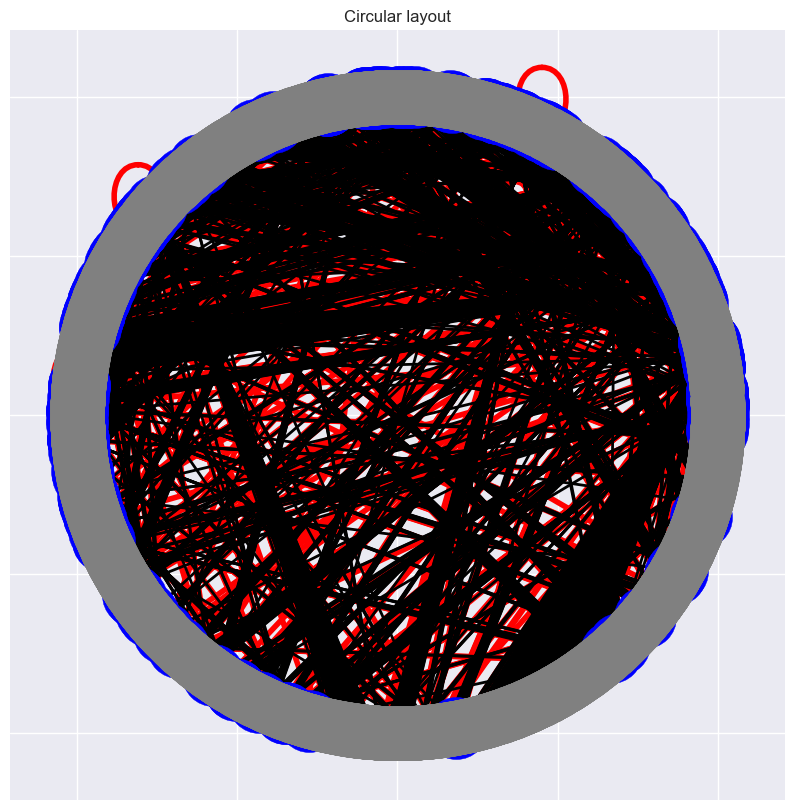

In [25]:
layout_name = 'Circular'
layout = nx.circular_layout(G_75)

draw(layout, layout_name)

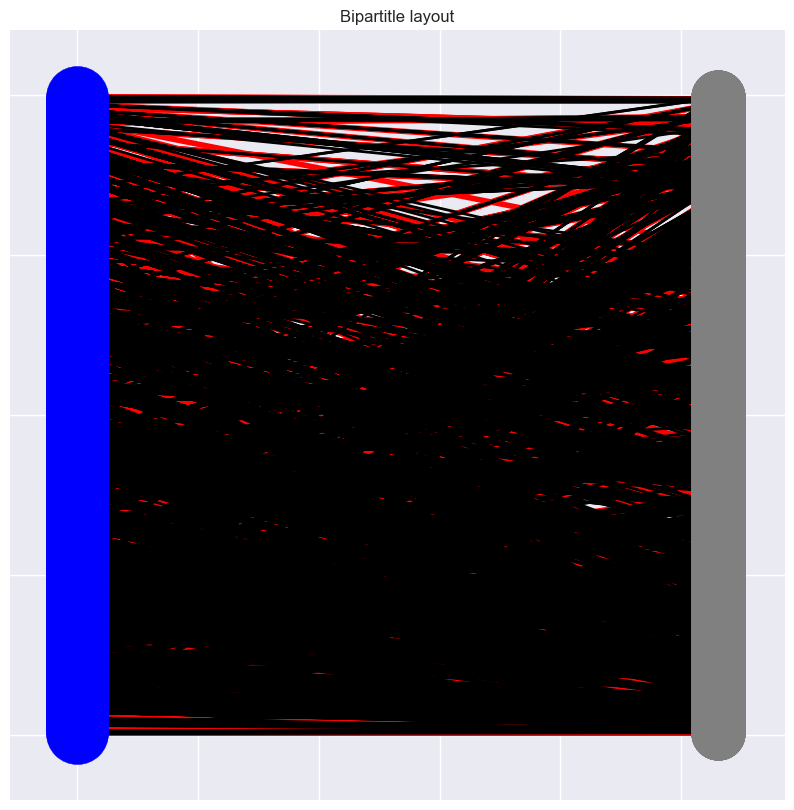

In [26]:
layout_name = 'Bipartitle'
layout = nx.bipartite_layout(G_75, reviewers)

draw(layout, layout_name)

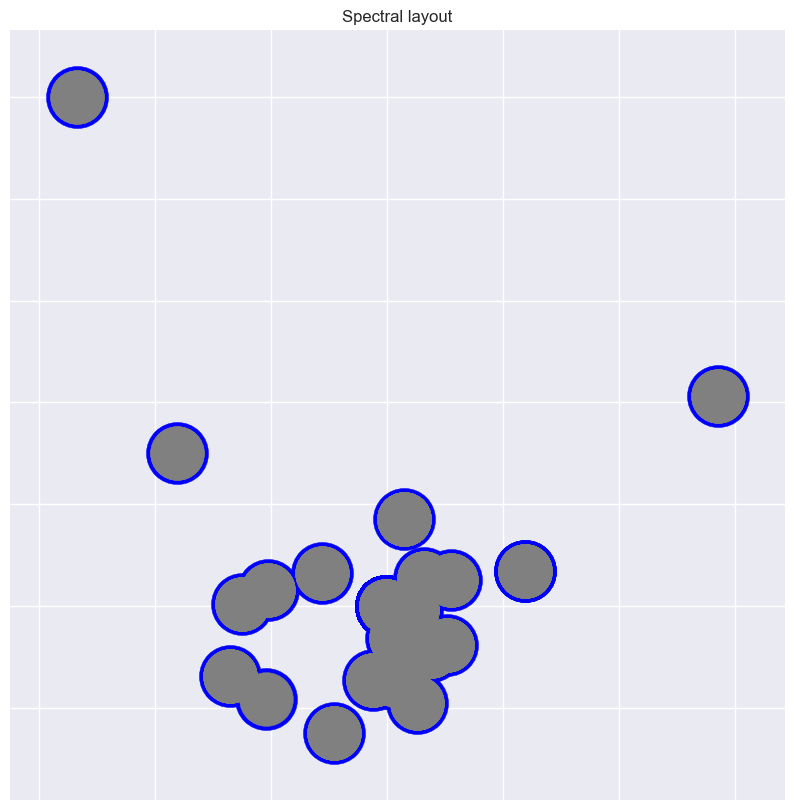

In [28]:
layout_name = 'Spectral'
layout = nx.spectral_layout(G_75)

draw(layout, layout_name)

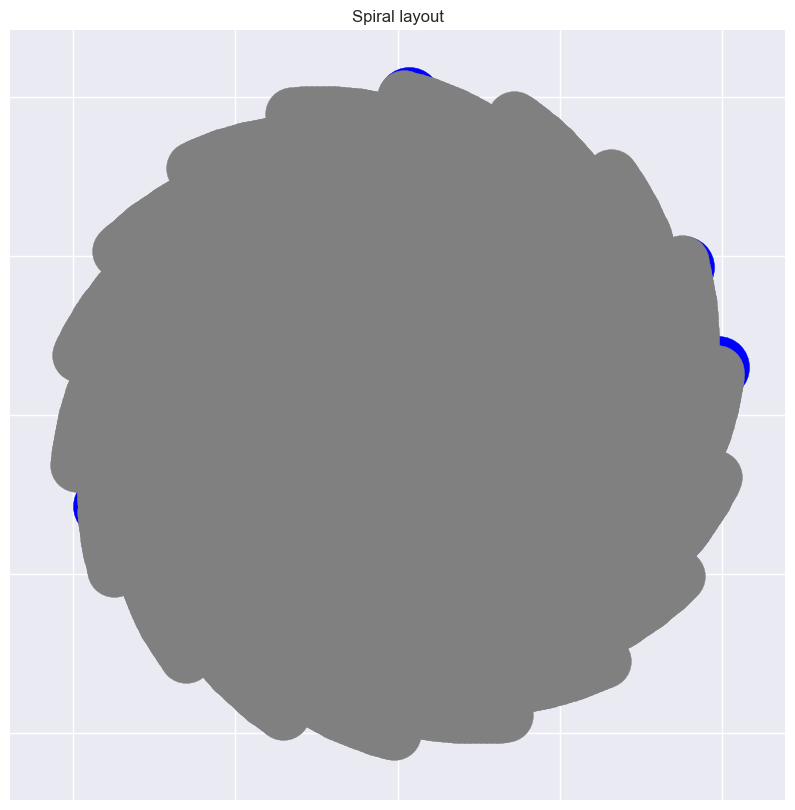

In [30]:
layout_name = 'Spiral'
layout = nx.spiral_layout(G_75)

draw(layout, layout_name)